In [1]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))

######################
## Define arguments ##
######################

# p <- ArgumentParser(description='')
# p$add_argument('--atlas_stages',    type="character",   nargs='+',  help='Atlas stage(s)')
# p$add_argument('--query_samples',   type="character",   nargs='+',  help='Query batch(es)')
# p$add_argument('--query_sce',       type="character",               help='SingleCellExperiment file for the query')
# p$add_argument('--atlas_sce',       type="character",               help='SingleCellExperiment file for the atlas')
# p$add_argument('--query_metadata',  type="character",               help='metadata file for the query')
# p$add_argument('--atlas_metadata',  type="character",               help='metadata file for the atlas')
# p$add_argument('--npcs',            type="integer",                 help='Number of principal components')
# p$add_argument('--n_neighbours',    type="integer",                 help='Number of neighbours')
# p$add_argument('--use_marker_genes',action = "store_true",          help='Use marker genes?')
# p$add_argument('--cosine_normalisation',      action = "store_true",          help='Use cosine normalisation?')
# p$add_argument('--test',            action = "store_true",          help='Testing mode')
# p$add_argument('--outfile',          type="character",               help='Output file')
# args <- p$parse_args(commandArgs(TRUE))

# #####################
## Define settings ##
#####################

# I/O
io$path2atlas <- io$atlas.basedir
io$path2query <- io$basedir


# Load mapping functions
source(here::here("rna/mapping/run/mnn/mapping_functions.R"))


## START TEST ##
args = list()
args$atlas_stages <- c("E6.5","E6.75","E7.0","E7.25","E7.5","E7.75","E8.0","E8.25","E8.5")
args$query_samples <- opts$samples
args$query_sce <- io$rna.sce
args$query_sce <- paste0(io$basedir,"/processed/rna/SingleCellExperiment.rds")
args$atlas_sce <- io$rna.atlas.sce
args$query_metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$atlas_metadata <- io$rna.atlas.metadata
args$test <- FALSE
args$npcs <- 50
args$n_neighbours <- 25
args$use_marker_genes <- FALSE
args$cosine_normalisation <- FALSE
args$outfolder <- paste0(io$basedir,"/code/rna/mapping/scVI_test")
## END TEST ##

if (isTRUE(args$test)) print("Test mode activated...")


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:

################
## Load query ##
################

# Load cell metadata
meta_query <- fread(args$query_metadata) %>% 
  .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$query_samples]
if (isTRUE(args$test)) meta_query <- head(meta_query,n=1000)

# Load SingleCellExperiment
sce_query <- load_SingleCellExperiment(args$query_sce, cells = meta_query$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_query %>% .[cell%in%colnames(sce_query)] %>% setkey(cell) %>% .[colnames(sce_query)]
stopifnot(tmp$cell == colnames(sce_query))
colData(sce_query) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_query),] %>% DataFrame()

In [3]:
################
## Load atlas ##
################

# Load cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stripped==F & doublet==F & stage%in%args$atlas_stages] %>%
  .[,sample:=factor(sample)]

# Filter
if (isTRUE(args$test)) meta_atlas <- head(meta_atlas,n=38346)

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(args$atlas_sce, normalise = TRUE, cells = meta_atlas$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_atlas %>% .[cell%in%colnames(sce_atlas)] %>% setkey(cell) %>% .[colnames(sce_atlas)]
stopifnot(tmp$cell == colnames(sce_atlas))
colData(sce_atlas) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_atlas),] %>% DataFrame()


In [4]:
sce_atlas
sce_query

class: SingleCellExperiment 
dim: 19379 108857 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(19379): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000063897 ENSMUSG00000095742
rowData names(0):
colnames(108857): cell_1 cell_10 ... cell_99998 cell_99999
colData names(11): barcode sample ... nFeature_RNA nCount_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 23004 38346 
metadata(0):
assays(1): counts
rownames(23004): Xkr4 Gm1992 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(38346): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(17): barcode sample ... day_celltype celltype_genotype
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [5]:
#############
## Prepare ## 
#############

# Rename ensemble IDs to gene names in the atlas
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

sce_atlas <- sce_atlas[rownames(sce_atlas)%in%gene_metadata$ens_id,]
foo <- gene_metadata$symbol; names(foo) <- gene_metadata$ens_id
rownames(sce_atlas) <- foo[rownames(sce_atlas)]

# Sanity checks
stopifnot(sum(is.na(rownames(sce_atlas)))==0)
stopifnot(sum(duplicated(rownames(sce_atlas)))==0)

stopifnot(TRUE %in% (meta_query$cell %in% meta_atlas$cell)==FALSE)

In [6]:
#####################
## Define gene set ##
#####################

# Intersect genes
genes.intersect <- intersect(rownames(sce_query), rownames(sce_atlas))

# Filter some genes manually
genes.intersect <- genes.intersect[grep("^Rik|Rik$|^mt-|^Rps-|^Rpl-|^Gm",genes.intersect,invert=T)]
genes.intersect <- genes.intersect[!genes.intersect=="Xist"]
genes.intersect <- genes.intersect[!genes.intersect%in%gene_metadata[chr=="chrY",symbol]]

# Subset SingleCellExperiment objects
sce_query  <- sce_query[genes.intersect,]
sce_atlas <- sce_atlas[genes.intersect,]

In [7]:
# sce_query = sce_query[,sample(ncol(sce_query), 10000)]
# sce_atlas = sce_atlas[,sample(ncol(sce_atlas), 20000)]


In [8]:
sce_query = logNormCounts(sce_query)
sce_atlas = logNormCounts(sce_atlas)

In [9]:
library(SingleR)

Warning message:
“package ‘SingleR’ was built under R version 4.1.2”


In [10]:
genes = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/results/marker_genes/all_stages/marker_genes.txt.gz")

In [11]:
gene_list  = lapply(unique(genes$celltype), function(x){
    tmp = genes[celltype==x,gene]
    tmp = tmp[tmp %in% genes.intersect]
    return(tmp)
})
names(gene_list) = unique(genes$celltype)


In [12]:
summary(genes$N)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   3.000   2.953   4.000   9.000 

# Pseudobulk

### With gene list

In [13]:
pred_celltype = SingleR(
                    sce_query,
                    sce_atlas,
                    labels = colData(sce_atlas)$celltype,
                    aggr.ref = TRUE,
                    genes = gene_list
                        )

Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


In [14]:
all.markers <- metadata(pred_celltype)$de.genes
sce_query$labels <- pred_celltype$labels

In [18]:
comparison.dt = as.data.table(table(sce_query$celltype, sce_query$labels)) %>%
    .[,freq:=N/sum(N), by=V2]

In [19]:
options(repr.plot.width=15, repr.plot.height=8)

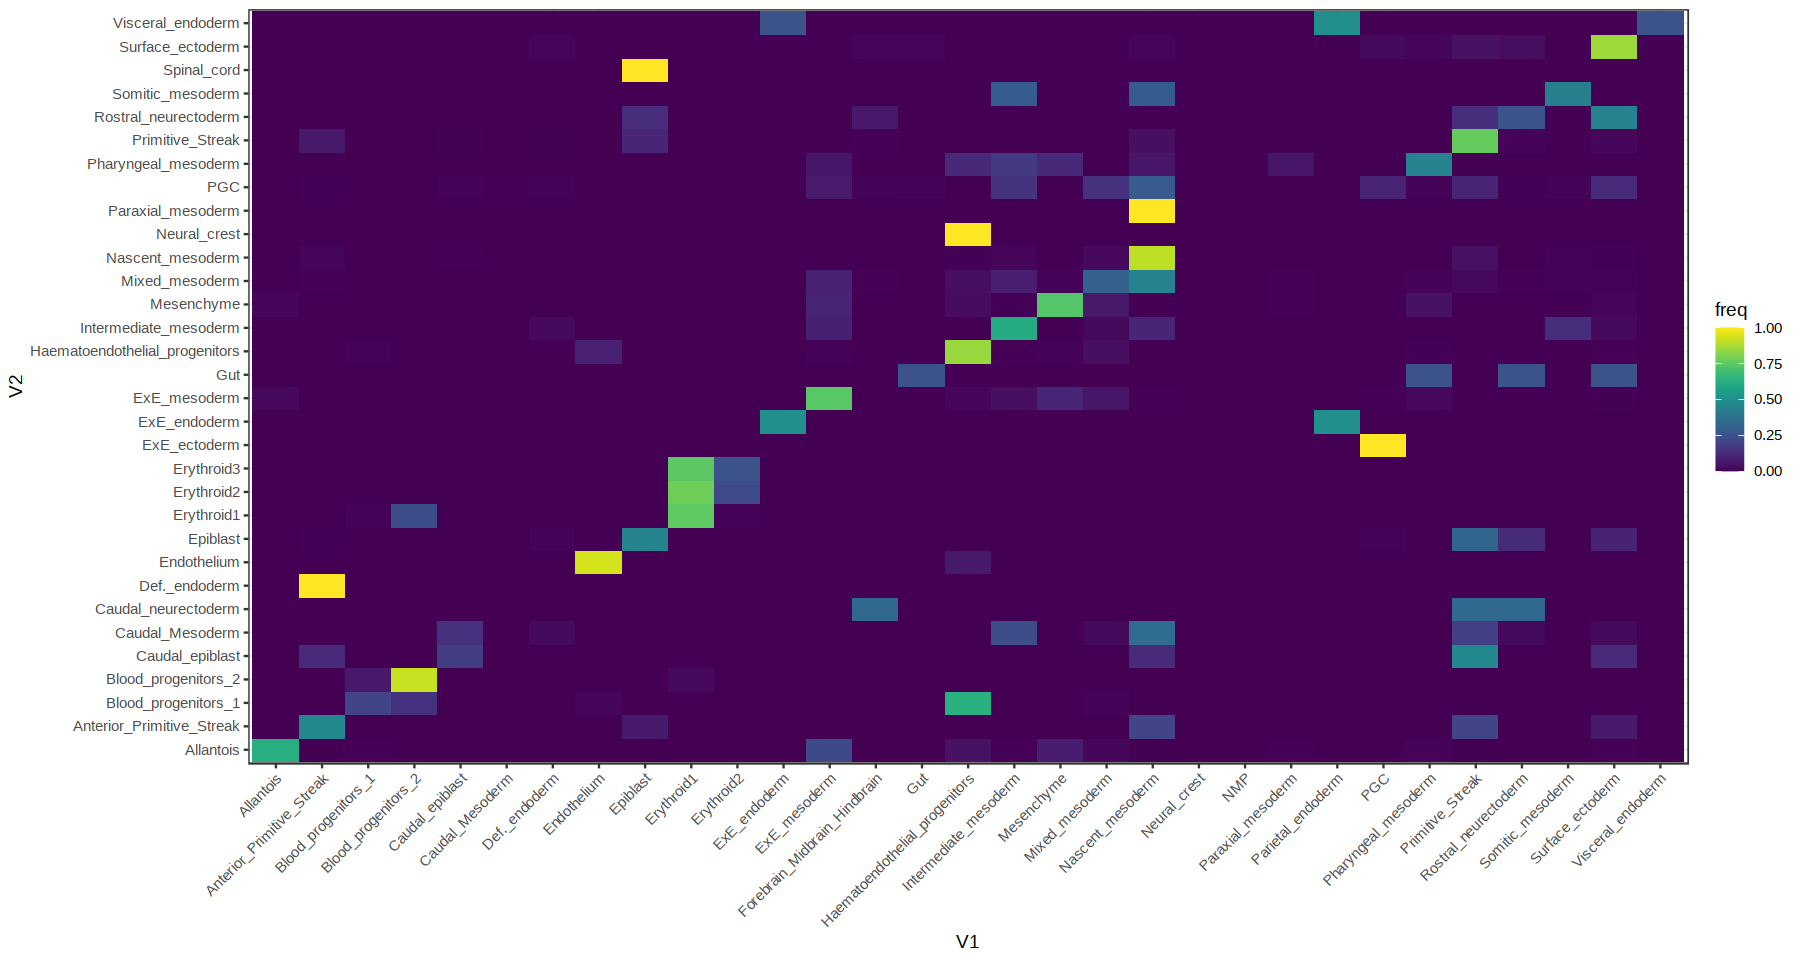

In [20]:
ggplot(comparison.dt, aes(V1, V2, fill=freq)) +
    geom_tile() + 
    viridis::scale_fill_viridis() + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1))

In [33]:
umap = fread("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/dimensionality_reduction/sce/batch_correction_None/umap_features2500_pcs50_neigh25_dist0.5.txt.gz")

In [35]:
summary(umap$cell == colnames(sce_query))

   Mode    TRUE 
logical   38346 

In [40]:
colData(sce_query) = colData(sce_query)[,1:19]

In [41]:
colData(sce_query) = cbind(colData(sce_query), umap[,c(1,2)])

In [42]:
meta = as.data.table(colData(sce_query)) 

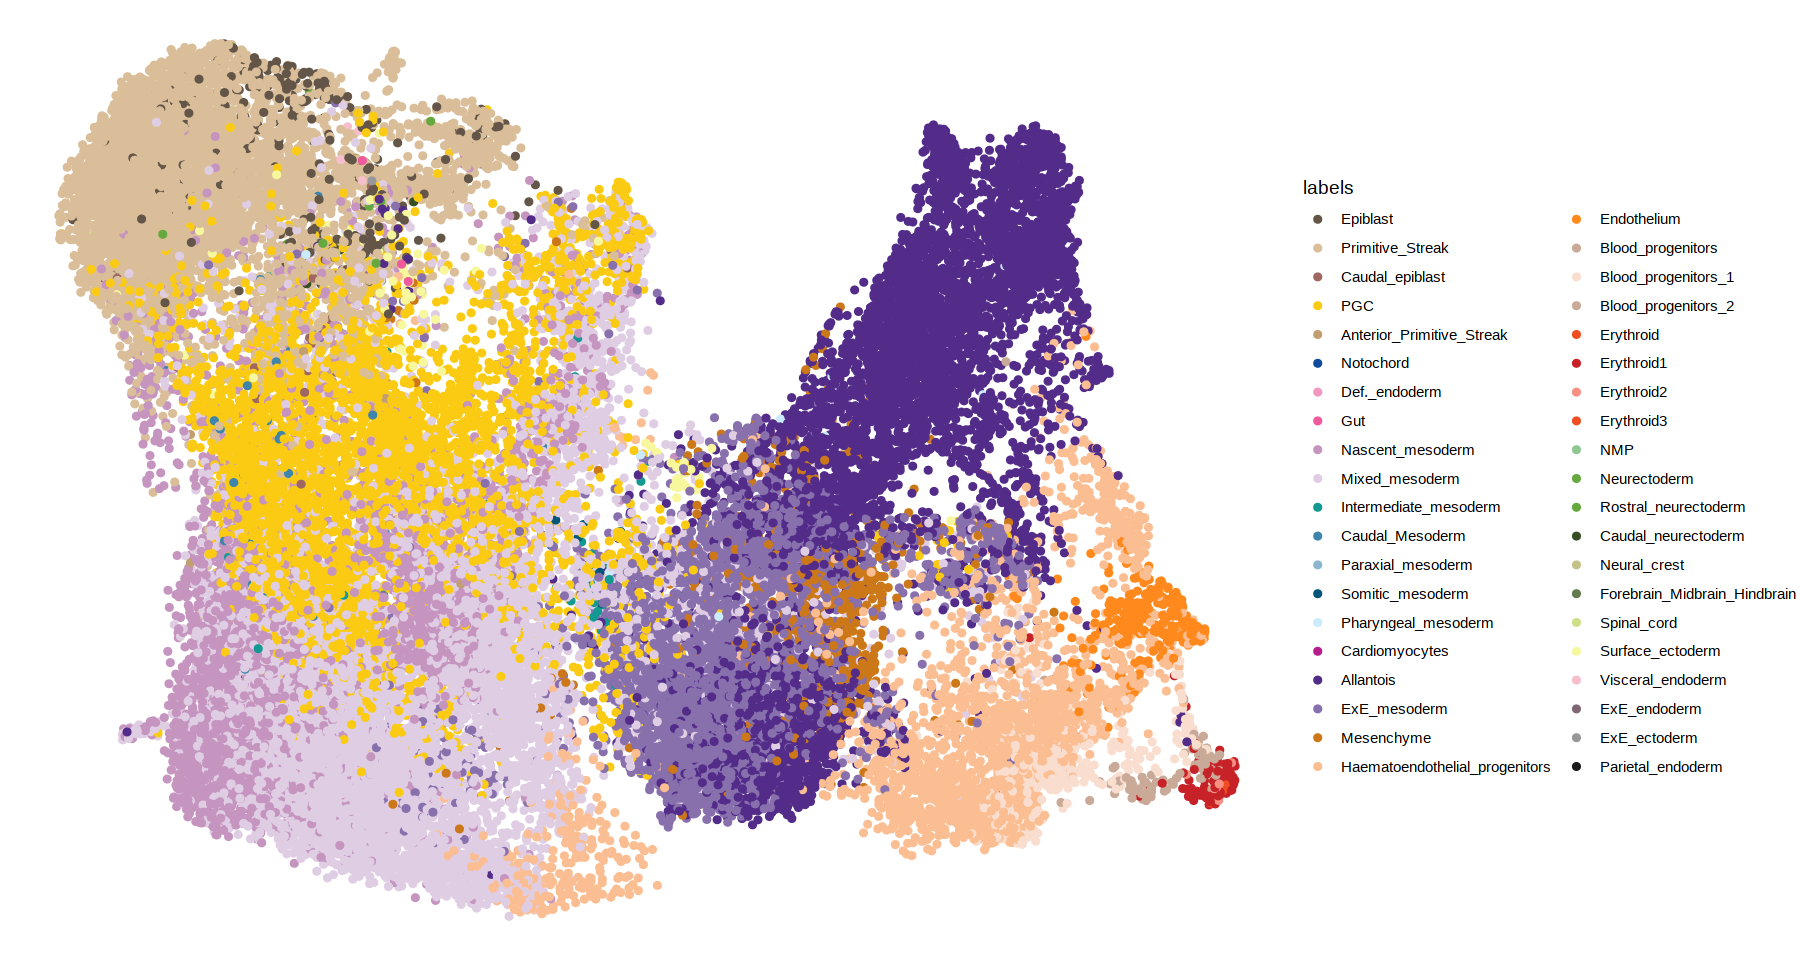

In [44]:
ggplot(meta, aes(UMAP1, UMAP2, col=labels)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

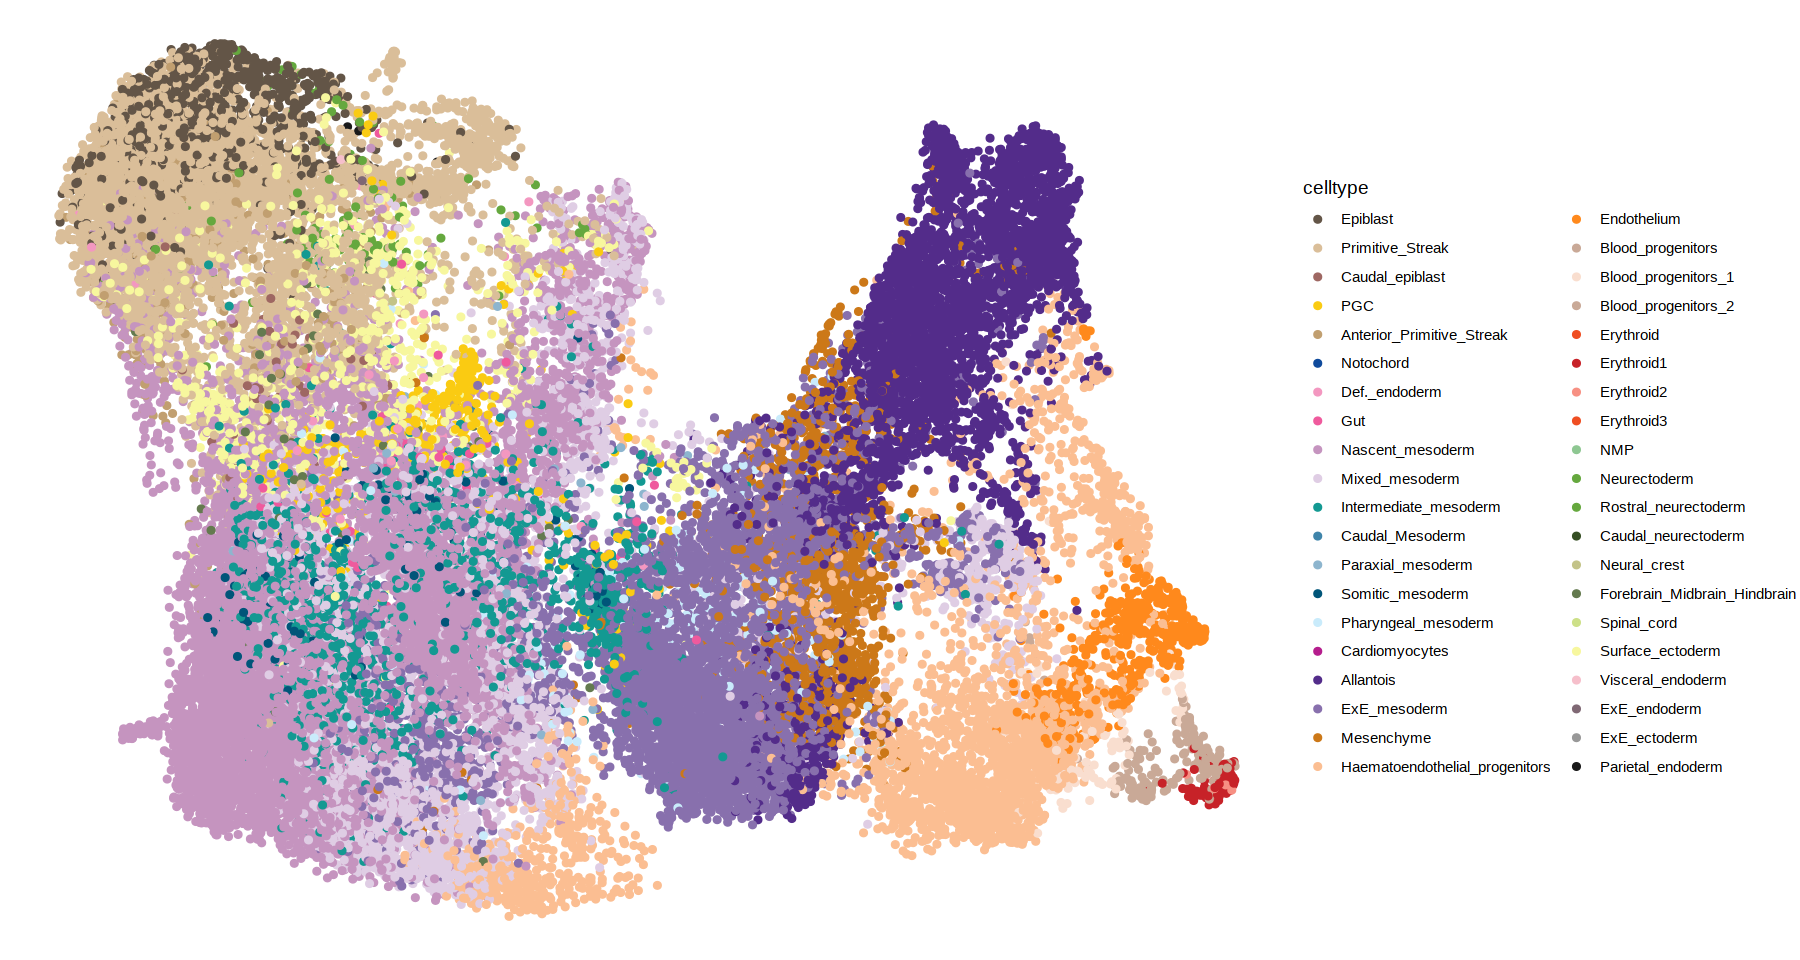

In [45]:
ggplot(meta, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

### Without supplying gene list

In [13]:
pred_celltype = SingleR(
                    sce_query,
                    sce_atlas,
                    labels = colData(sce_atlas)$celltype,
                    aggr.ref = TRUE
                        )

Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


In [14]:
all.markers <- metadata(pred_celltype)$de.genes
sce_query$labels <- pred_celltype$labels

In [15]:
comparison.dt = as.data.table(table(sce_query$celltype, sce_query$labels)) %>%
    .[,freq:=N/sum(N), by=V2]

In [16]:
options(repr.plot.width=15, repr.plot.height=8)

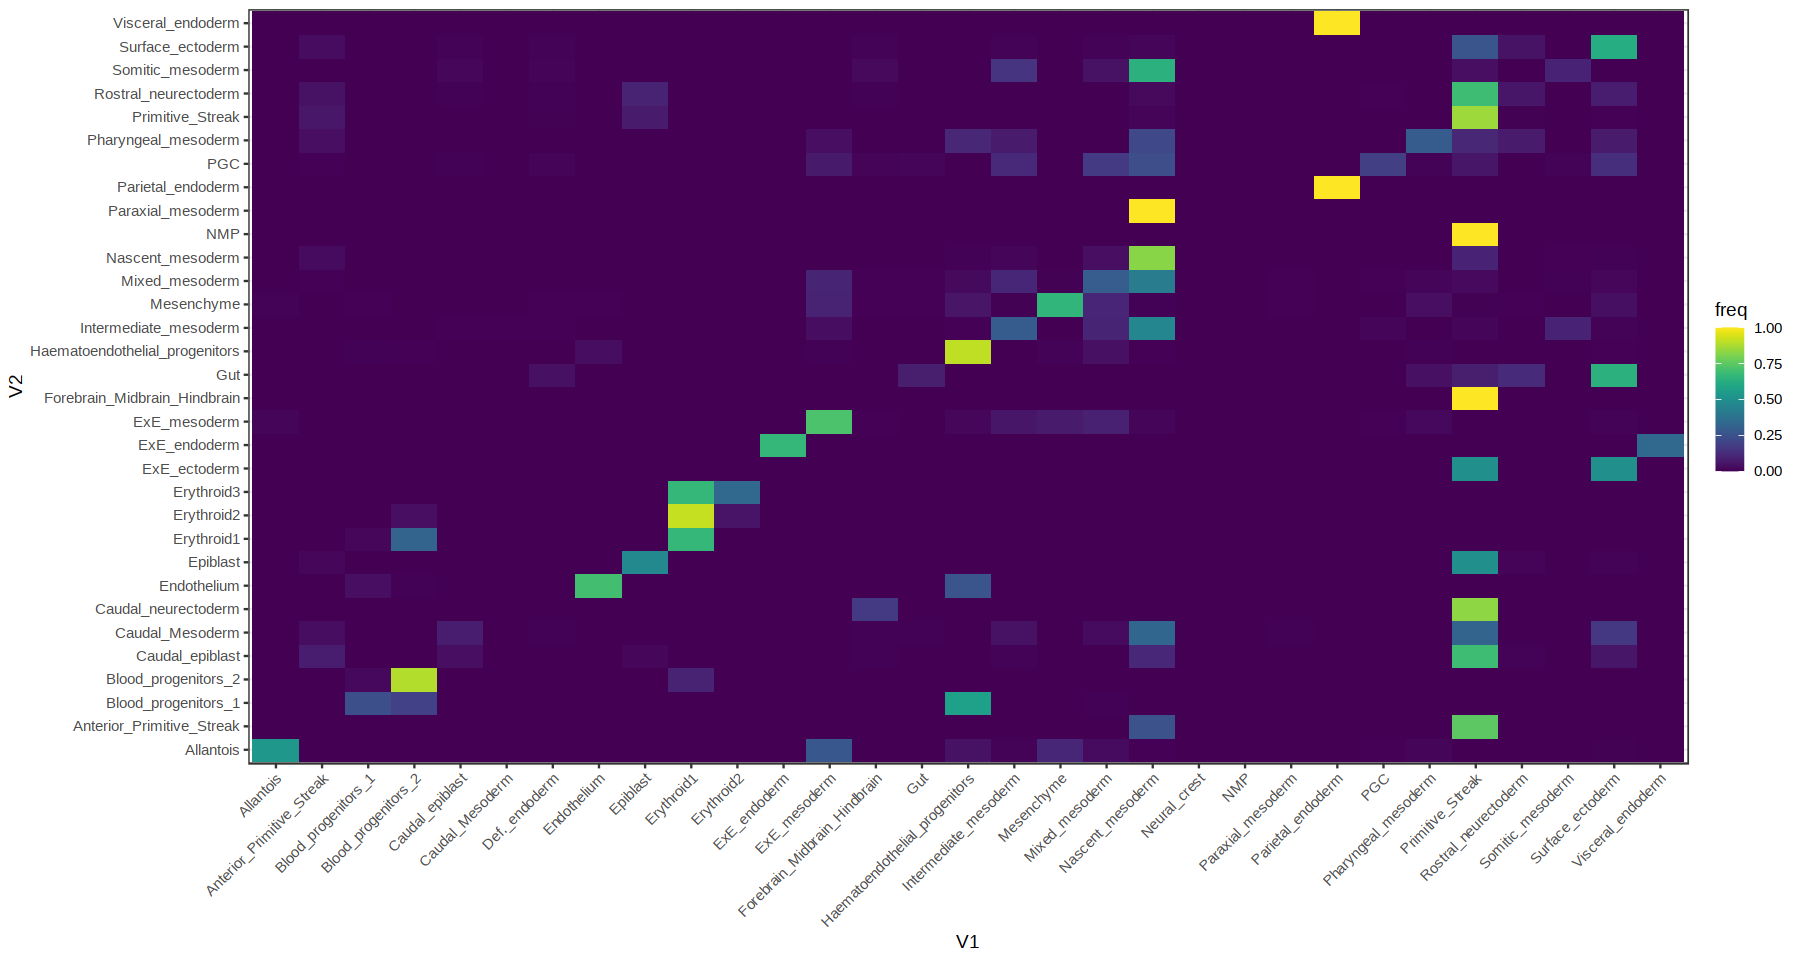

In [17]:
ggplot(comparison.dt, aes(V1, V2, fill=freq)) +
    geom_tile() + 
    viridis::scale_fill_viridis() + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1))

In [18]:
umap = fread("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/dimensionality_reduction/sce/batch_correction_None/umap_features2500_pcs50_neigh25_dist0.5.txt.gz")

In [19]:
summary(umap$cell == colnames(sce_query))

   Mode    TRUE 
logical   38346 

In [20]:
colData(sce_query) = colData(sce_query)[,1:19]

In [21]:
colData(sce_query) = cbind(colData(sce_query), umap[,c(1,2)])

In [22]:
meta = as.data.table(colData(sce_query)) 

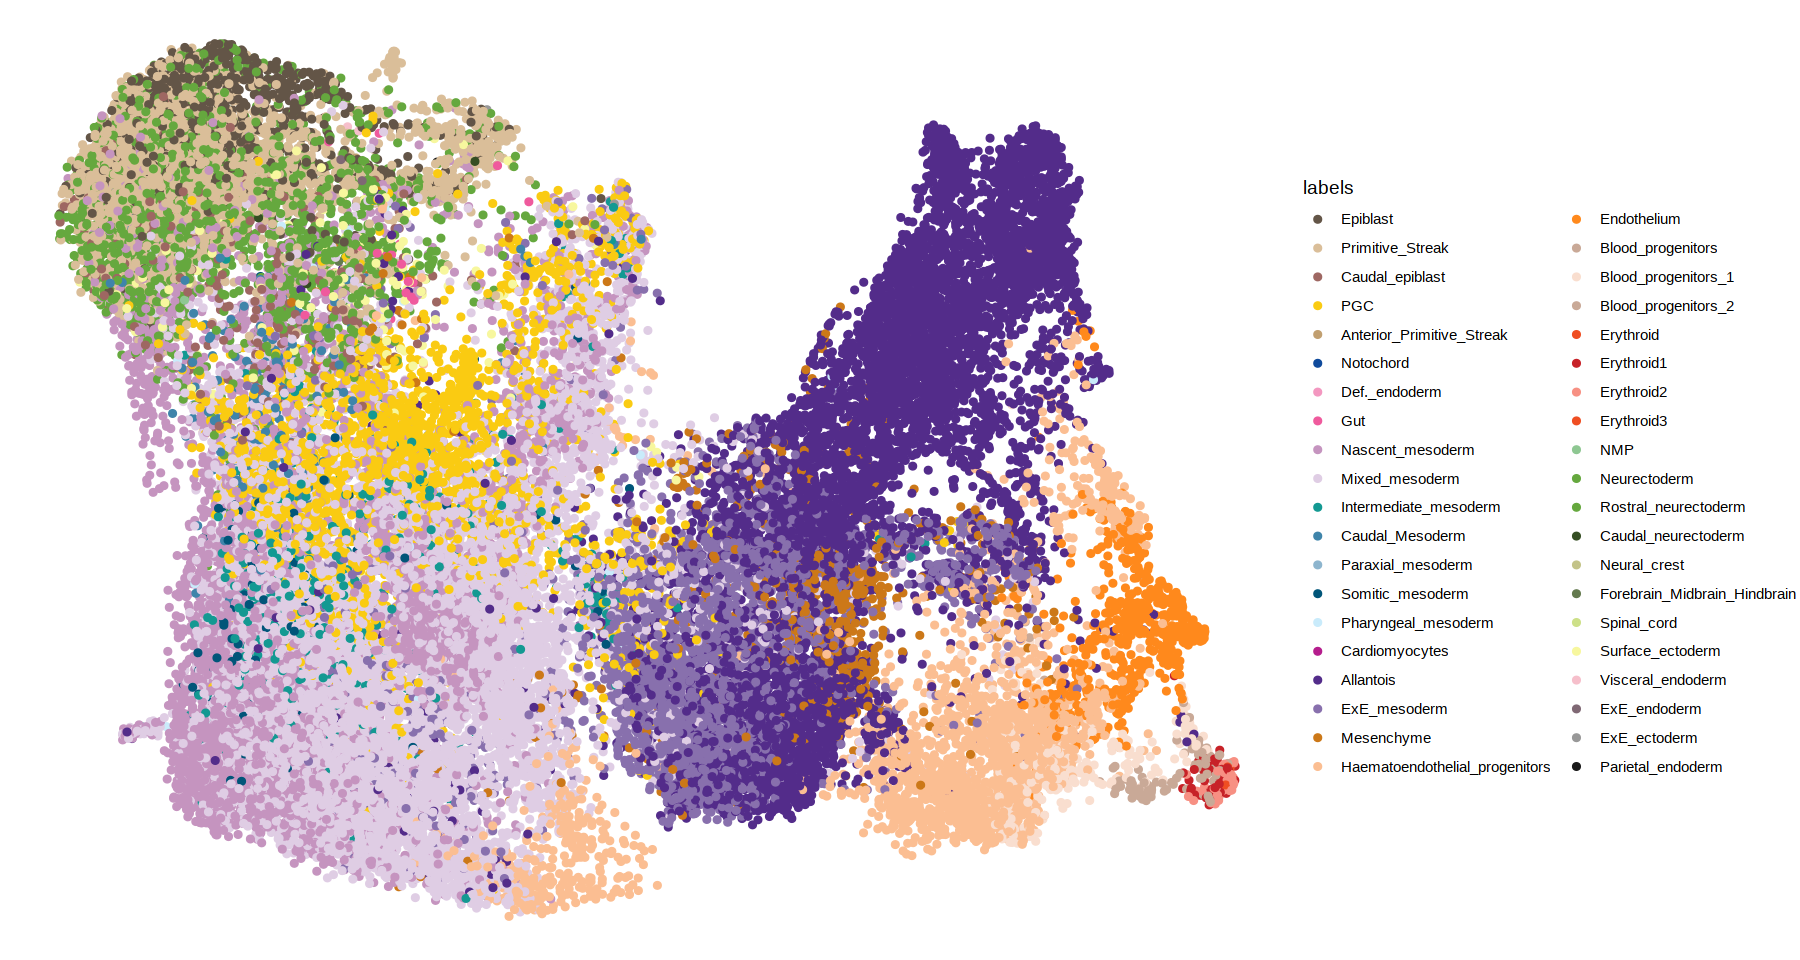

In [23]:
ggplot(meta, aes(UMAP1, UMAP2, col=labels)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

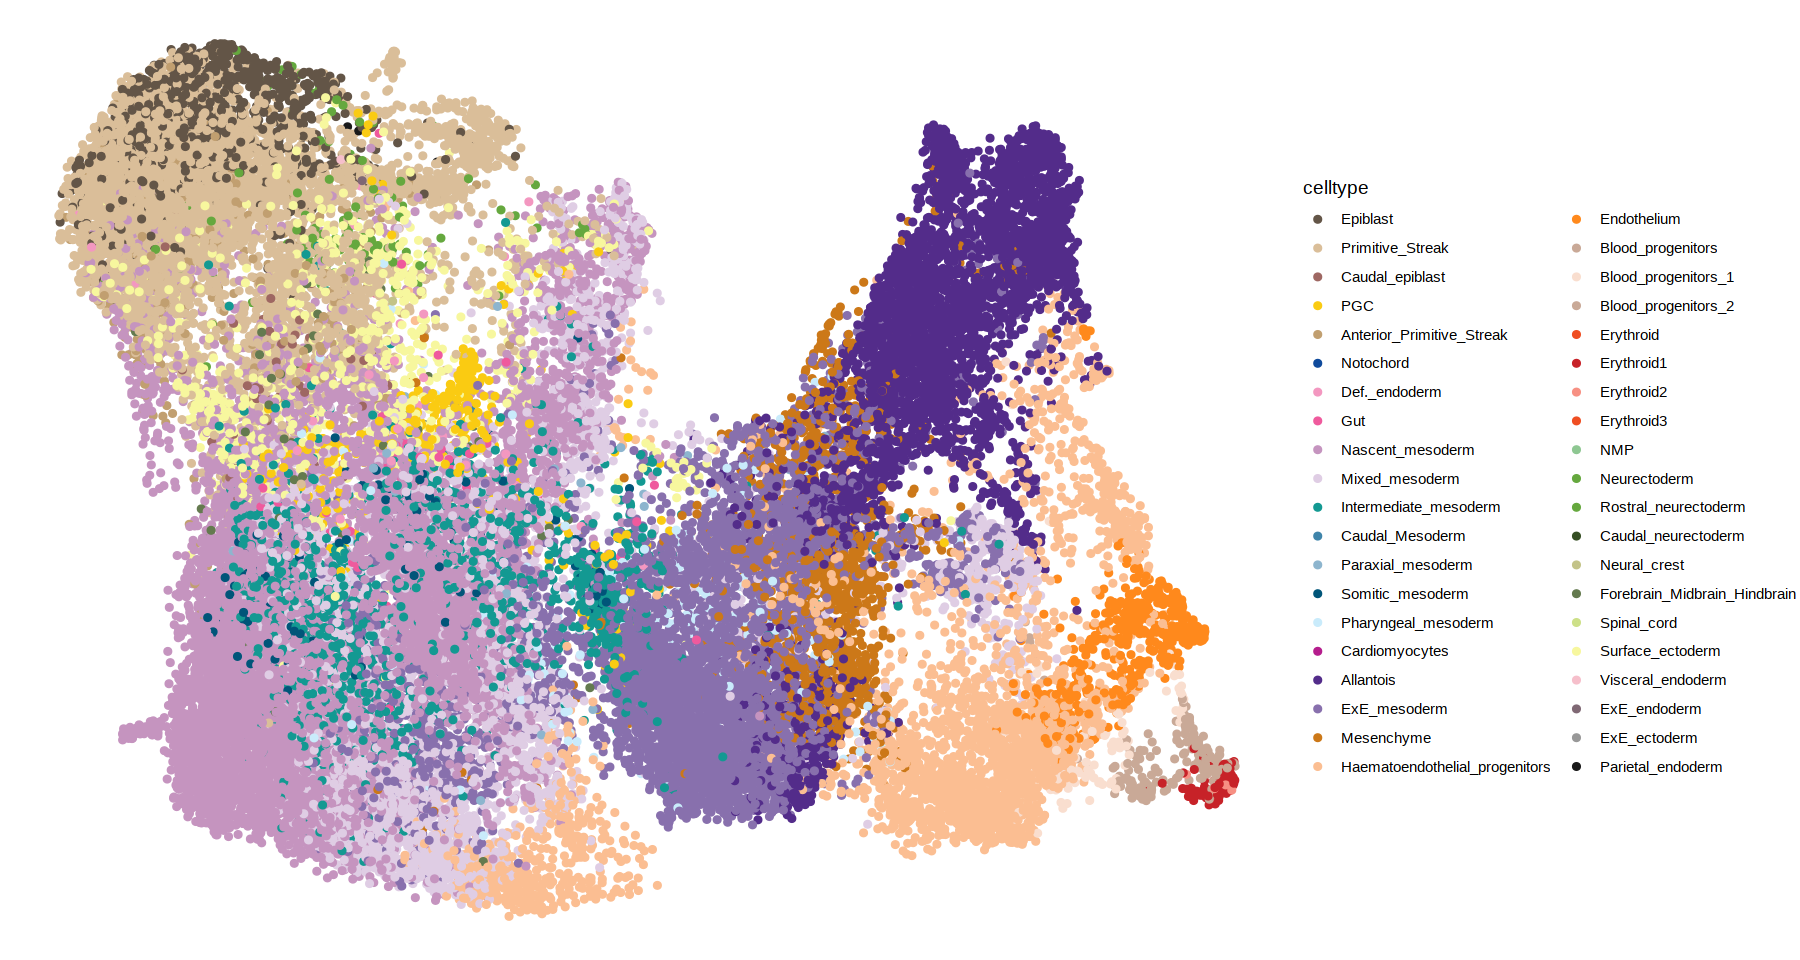

In [24]:
ggplot(meta, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

# Not Pseudobulked

### With gene list

In [ ]:
pred_celltype = SingleR(
                    sce_query,
                    sce_atlas,
                    labels = colData(sce_atlas)$celltype,
                    genes = gene_list
                        )

In [ ]:
all.markers <- metadata(pred_celltype)$de.genes
sce_query$labels <- pred_celltype$labels

In [ ]:
comparison.dt = as.data.table(table(sce_query$celltype, sce_query$labels)) %>%
    .[,freq:=N/sum(N), by=V2]

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)

In [ ]:
ggplot(comparison.dt, aes(V1, V2, fill=freq)) +
    geom_tile() + 
    viridis::scale_fill_viridis() + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1))

In [ ]:
umap = fread("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/dimensionality_reduction/sce/batch_correction_None/umap_features2500_pcs50_neigh25_dist0.5.txt.gz")

In [ ]:
summary(umap$cell == colnames(sce_query))

In [ ]:
colData(sce_query) = colData(sce_query)[,1:19]

In [ ]:
colData(sce_query) = cbind(colData(sce_query), umap[,c(1,2)])

In [ ]:
meta = as.data.table(colData(sce_query)) 

In [ ]:
ggplot(meta, aes(UMAP1, UMAP2, col=labels)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

In [ ]:
ggplot(meta, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

### Without supplying gene list

In [ ]:
pred_celltype = SingleR(
                    sce_query,
                    sce_atlas,
                    labels = colData(sce_atlas)$celltype
                        )

In [ ]:
all.markers <- metadata(pred_celltype)$de.genes
sce_query$labels <- pred_celltype$labels

In [ ]:
comparison.dt = as.data.table(table(sce_query$celltype, sce_query$labels)) %>%
    .[,freq:=N/sum(N), by=V2]

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)

In [ ]:
ggplot(comparison.dt, aes(V1, V2, fill=freq)) +
    geom_tile() + 
    viridis::scale_fill_viridis() + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1))

In [ ]:
umap = fread("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/dimensionality_reduction/sce/batch_correction_None/umap_features2500_pcs50_neigh25_dist0.5.txt.gz")

In [ ]:
summary(umap$cell == colnames(sce_query))

In [ ]:
colData(sce_query) = colData(sce_query)[,1:19]

In [ ]:
colData(sce_query) = cbind(colData(sce_query), umap[,c(1,2)])

In [ ]:
meta = as.data.table(colData(sce_query)) 

In [ ]:
ggplot(meta, aes(UMAP1, UMAP2, col=labels)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()

In [ ]:
ggplot(meta, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point() +
    scale_color_manual(values=opts$celltype.colors) +
    theme_void()